(213, 9)
winner
1    145
0     68
Name: count, dtype: int64
event
All England Open 2024                31
Singapore Open 2024                  31
Indonesia Open 2024                  31
India Open 2024                      30
Badminton Asia Championships 2024    30
Thailand Open 2024                   30
Malaysia Masters 2024                30
Name: count, dtype: int64


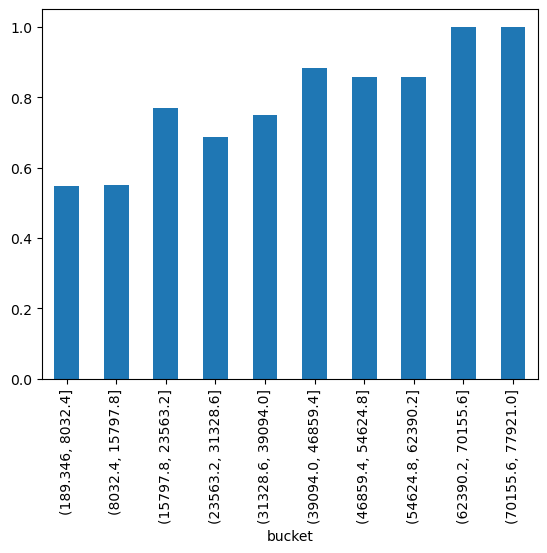

R² = 0.0747


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

df = pd.read_csv("data/training_matches_synced.csv")
print(df.shape)
print(df["winner"].value_counts())  # how often does the favourite win?
print(df["event"].value_counts())   # matches per tournament

# plot point_diff vs win rate — does a bigger gap = more wins?
df["bucket"] = pd.cut(df["point_diff"], bins=10)
df.groupby("bucket")["winner"].mean().plot(kind="bar")
plt.show()

# Prepare data - drop rows where either column is NaN
clean = df[["point_diff", "winner"]].dropna()
X = clean[["point_diff"]]  # 2D array for sklearn
y = clean["winner"]

# Fit and score
model = LinearRegression()
model.fit(X, y)
print(f"R² = {model.score(X, y):.4f}")